### Setup

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Imports
import sys
from pathlib import Path
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, SaliencyMapMethod, CarliniL2Method

sys.path.append(str(Path.cwd().parents[2]))

from utils.functions import get_windowed_data
from utils.notebook import get_model_classifier, clean_data_test, adv_test, FilenameLoader, get_filename_from_path

/opt/anaconda3/envs/reu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Model and Data

In [14]:
## Inputs
data_name = FilenameLoader.rand_pos()[1]

checkpoint_folder= f"../../../saved_models/decen/init-test-randpos/*"
data_file = f"../../../data/{data_name}"
save_path = "../final_data/randpos"

In [6]:
## Load data
# Load data
(x_train, y_train), (x_test, y_test), fed_dataset, scaler = get_windowed_data(data_file, 
                                                                      normalize=True, 
                                                                      train_perc=80)

In [15]:
import glob 

vehicles = glob.glob(checkpoint_folder)
print(vehicles)
for i in range(len(vehicles)):
    checkpoint_file = vehicles[i]
    model, classifier = get_model_classifier(checkpoint_file)

    filename = get_filename_from_path (checkpoint_file)
    out = clean_data_test(model = model, classifier = classifier, # model information
                x_test=x_test, y_test=y_test, # data information
                checkpoint_file=checkpoint_file, data_file=data_file, # to save in json
                save_path="../data-test", filename=f"clean_{filename}.json", # saving information
                save_results=False
                ) 
    print(out)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/reu/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


['../../../saved_models/decen/init-test-randpos/vehicle_119_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_49_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_81_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_0_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_184_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_37_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_150_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_167_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_62_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_55_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_132_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_105_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_198_model.ckpt', '../../../saved_models/decen/init-test-randpos/vehicle_189_model.ckpt'

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


save=False, Metrics not saved
Metrics {'noWrapper': {'accuracy': 0.972798018818023, 'recall': 0.9088535203668735, 'precision': 0.9995460816163054, 'f1': 0.9520448171356312, 'falseNegativeRate': 0.09114647963312651, 'falsePositiveRate': 0.00017445042415397245, 'TP': 336912, 'TN': 876887, 'FP': 153, 'FN': 33788}, 'wrapper': {'accuracy': 0.972798018818023, 'precision': 0.9995460816163054, 'recall': 0.9088535203668735, 'f1': 0.9520448171356312, 'falseNegativeRate': 0.09114647963312651, 'falsePositiveRate': 0.00017445042415397245, 'TP': 336912, 'TN': 876887, 'FP': 153, 'FN': 33788}, 'files': {'checkpointFile': '../../../saved_models/decen/init-test-randpos/vehicle_119_model.ckpt', 'dataFile': '../../../data/RandomPos_0709.csv'}}
{'noWrapper': {'accuracy': 0.972798018818023, 'recall': 0.9088535203668735, 'precision': 0.9995460816163054, 'f1': 0.9520448171356312, 'falseNegativeRate': 0.09114647963312651, 'falsePositiveRate': 0.00017445042415397245, 'TP': 336912, 'TN': 876887, 'FP': 153, 'FN':

KeyboardInterrupt: 

### Wrapper Tests

In [ ]:


# for i in range(len(vehicles)):
#     vehicle_file = vehicles[i]
#     model, classifier = get_classifier(vehicle_file)
#     benign_test(in_model=model,
#                 in_classifier = classifier,
#                 save_path="./data-test",
#                 filename = f"benign_{prettify_filename(vehicle_file)}.json", 
#                 checkpoint_file=vehicle_file)
    
for i in range(len(vehicles)):
    checkpoint_file = vehicles[i]
    model, classifier = get_model_classifier(checkpoint_file)

    save_path = "../data-test/randpos/fgsm"
    filename = f"adv_eps_0.1_{get_filename_from_path(checkpoint_file)}.json"
    adv_test(end_index = len(y_test.numpy()),
        path = save_path,
        filename=filename,
        in_classifier=classifier,
        Attack=FastGradientMethod,
        eps=0.1,
        )

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/reu/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Checkpoint path exists!
=== Attack: FastGradientMethod, kwargs: {'eps': 0.1} ===


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Accuracy:           0.8048
Precision:          0.6620
Recall:             0.7008
F1:                 0.6808
ASR (FNR):          0.2992
False Positive Rate:0.1512
TP=259775, TN=744423, FP=132617, FN=110925
Time elapsed:       16.05s
Saved metrics to ../data-test/randpos/fgsm/adv_eps_0.1_vehicle_119_model.json
Checkpoint path exists!
=== Attack: FastGradientMethod, kwargs: {'eps': 0.1} ===


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Accuracy:           0.8617
Precision:          0.8554
Recall:             0.6432
F1:                 0.7343
ASR (FNR):          0.3568
False Positive Rate:0.0460
TP=238425, TN=836733, FP=40307, FN=132275
Time elapsed:       16.95s
Saved metrics to ../data-test/randpos/fgsm/adv_eps_0.1_vehicle_142_model.json
Checkpoint path exists!
=== Attack: FastGradientMethod, kwargs: {'eps': 0.1} ===


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Accuracy:           0.8086
Precision:          0.9981
Recall:             0.3564
F1:                 0.5252
ASR (FNR):          0.6436
False Positive Rate:0.0003
TP=132105, TN=876789, FP=251, FN=238595
Time elapsed:       16.79s
Saved metrics to ../data-test/randpos/fgsm/adv_eps_0.1_vehicle_175_model.json
Checkpoint path exists!
=== Attack: FastGradientMethod, kwargs: {'eps': 0.1} ===


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Accuracy:           0.8222
Precision:          0.9984
Recall:             0.4021
F1:                 0.5733
ASR (FNR):          0.5979
False Positive Rate:0.0003
TP=149058, TN=876807, FP=233, FN=221642
Time elapsed:       16.66s
Saved metrics to ../data-test/randpos/fgsm/adv_eps_0.1_vehicle_12_model.json
Checkpoint path exists!
=== Attack: FastGradientMethod, kwargs: {'eps': 0.1} ===
Accuracy:           0.8403
Precision:          0.9984
Recall:             0.4631
F1:                 0.6327
ASR (FNR):          0.5369
False Positive Rate:0.0003
TP=171656, TN=876768, FP=272, FN=199044
Time elapsed:       17.10s
Saved metrics to ../data-test/randpos/fgsm/adv_eps_0.1_vehicle_25_model.json


In [43]:
# vehicles = glob.glob("../data-test/randpos/benign/*")
vehicles = glob.glob("../data-test/randpos/fgsm/*")

f1_scores = []

for veh_file in vehicles:
    with open(veh_file, "r") as veh:
        veh_json = json.load(veh)
        # f1_scores.append(veh_json["wrapper"]["f1"])
        f1_scores.append(veh_json["metrics"]["f1"])

f1_avg = sum(f1_scores) / len(f1_scores)

f1_avg

0.5937189128614161

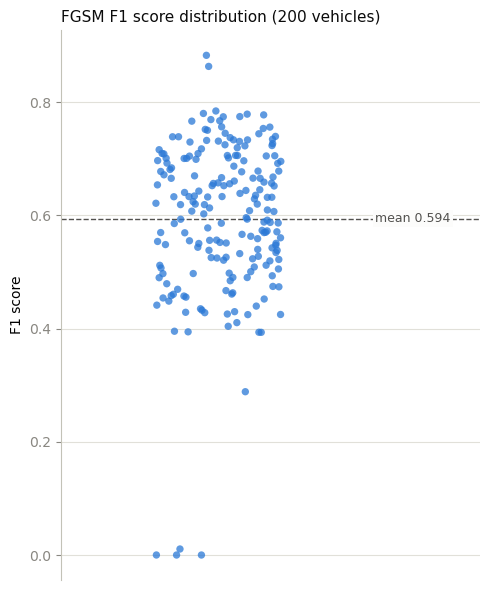

In [45]:
# Point plot of the per-vehicle F1 scores, to see the distribution behind f1_avg
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 6))

rng = np.random.default_rng(0)
jitter = rng.uniform(-0.12, 0.12, size=len(f1_scores))

ax.scatter(jitter, f1_scores, s=28, facecolor="#2a78d6", edgecolor="none", alpha=0.75, zorder=3)

mean_f1 = float(np.mean(f1_scores))
ax.axhline(mean_f1, color="#52514e", linestyle="--", linewidth=1, zorder=2)
ax.text(0.3, mean_f1, f"mean {mean_f1:.3f}", color="#52514e", fontsize=9,
        va="center", ha="left",
        bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=1.5))

ax.set_xlim(-0.3, 0.5)
ax.set_xticks([])
ax.set_ylabel("F1 score")
ax.set_title(f"FGSM F1 score distribution ({len(f1_scores)} vehicles)",
             fontsize=11, color="#0b0b0b", loc="left")

for spine in ("top", "right", "bottom"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()